In [1]:
import pandas as pd

In [2]:
# Check the raw data first
df = pd.read_csv("model_properties.csv")


In [3]:
# Check dataframe structure
print(df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")   

import matplotlib.pyplot as plt
import numpy as np

# Rename columns for easier access
df.columns = ['solute', 'model', 'heat_of_vaporization', 
              'heat_capacity', 'compressibility',
              'thermal_expansion', 'density']

# Remove rows with missing solute
df_clean = df[df['solute'].notna()].copy()

# Standardize NMA capitalization
df_clean.loc[df_clean['solute'].str.lower() == 'nma', 'solute'] = 'NMA'

print(f"Data shape: {df_clean.shape}")
print(f"Unique solutes: {df_clean['solute'].unique()}")

df.head()


(36, 7)

Column names:
['solute', 'model', 'heat_of_vaporization', 'heat_capacity', 'compressibility', 'thermal_expansion', 'density']

First few rows:
Data shape: (36, 7)
Unique solutes: ['Water' 'Benzene' 'Hexane' 'Acetone' 'Methanol' 'NMA']
Data shape: (36, 7)
Unique solutes: ['Water' 'Benzene' 'Hexane' 'Acetone' 'Methanol' 'NMA']


,solute,model,heat_of_vaporization,heat_capacity,compressibility,thermal_expansion,density
0,Water,GRACE (2L-S),42.37,1.61,0.45,0.05,1.013
1,Water,GRACE (2L-M),43.46,1.58,0.42,0.01,1.000
2,Water,GRACE (2L-L),43.19,1.5,0.46,0.05,1.009
3,Benzene,GRACE (2L-S),37.56,1.09,0.52,0.11,1.000
4,Benzene,GRACE (2L-M),28.04,1.08,0.7,0.12,0.959


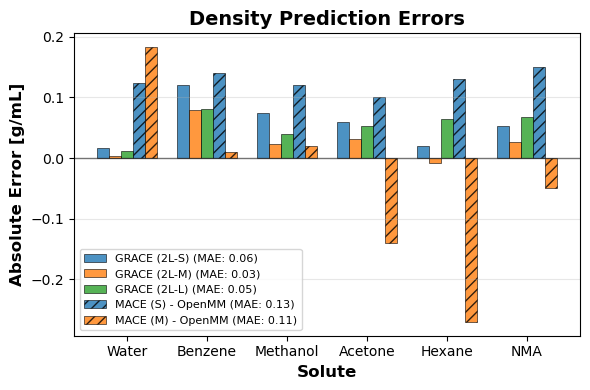

In [4]:
# Create bar plot showing difference to experimental values
fig, ax = plt.subplots(figsize=(6, 4))

# Get experimental data
exp_data = df_clean[df_clean["model"] == "experiment"]
# Include all models except experiment
model_data = df_clean[df_clean["model"] != "experiment"]

# Define colors for model sizes (S, M, L)
size_colors = {
    "S": "#1f77b4",  # blue
    "M": "#ff7f0e",  # orange
    "L": "#2ca02c",  # green
}

# Get unique solutes and models
solutes = exp_data["solute"].unique()
models = model_data["model"].unique()

# Calculate differences for each model and solute
differences_data = []

for model in models:
    model_subset = model_data[model_data["model"] == model]
    
    # Determine model size for color
    model_size = None
    if "(2L-S)" in model or "(S)" in model:
        model_size = "S"
    elif "(2L-M)" in model or "(M)" in model:
        model_size = "M"
    elif "(2L-L)" in model or "(L)" in model:
        model_size = "L"
    
    color = size_colors.get(model_size, "gray")
    
    for solute in solutes:
        exp_val = exp_data[exp_data["solute"] == solute]["density"].values
        mod_val = model_subset[model_subset["solute"] == solute]["density"].values
        
        if len(exp_val) > 0 and len(mod_val) > 0:
            exp_v = exp_val[0]
            mod_v = mod_val[0]
            
            if pd.notna(exp_v) and pd.notna(mod_v):
                diff = mod_v - exp_v
                differences_data.append({
                    'model': model,
                    'solute': solute,
                    'difference': diff,
                    'color': color
                })

# Create DataFrame for plotting
df_diff = pd.DataFrame(differences_data)

# Create grouped bar plot
x = np.arange(len(solutes))
width = 0.15
offsets = np.linspace(-width * (len(models)-1)/2, width * (len(models)-1)/2, len(models))

for i, model in enumerate(models):
    model_data_subset = df_diff[df_diff['model'] == model]
    values = []
    
    # Determine model size for color (once per model)
    model_size = None
    if "(2L-S)" in model or "(S)" in model:
        model_size = "S"
    elif "(2L-M)" in model or "(M)" in model:
        model_size = "M"
    elif "(2L-L)" in model or "(L)" in model:
        model_size = "L"
    
    color = size_colors.get(model_size, "gray")
    
    for solute in solutes:
        solute_data = model_data_subset[model_data_subset['solute'] == solute]
        if len(solute_data) > 0:
            values.append(solute_data['difference'].values[0])
        else:
            values.append(0)
    
    # Calculate MAE for this model
    mae = np.mean(np.abs(values))
    
    # Add hatch pattern for MACE models
    hatch = '///' if 'MACE' in model else None
    
    ax.bar(x + offsets[i], values, width, label=f"{model} (MAE: {mae:.2f})", 
           color=color, alpha=0.8, hatch=hatch, edgecolor='black', linewidth=0.5)

# Add zero line
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)

ax.set_xlabel('Solute', fontweight='bold', fontsize=12)
ax.set_ylabel('Absolute Error [g/mL]', fontweight='bold', fontsize=12)
ax.set_title('Density Prediction Errors', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(solutes, rotation=0)
ax.legend(fontsize=8, loc='best')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

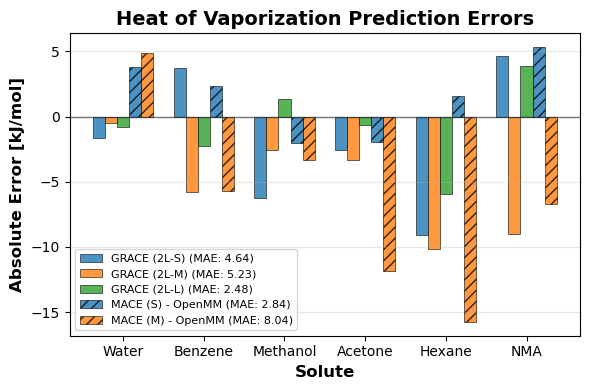

In [5]:
# Create bar plot showing difference to experimental values for heat of vaporization
fig, ax = plt.subplots(figsize=(6, 4))

# Get experimental data
exp_data = df_clean[df_clean["model"] == "experiment"]
# Include all models except experiment
model_data = df_clean[df_clean["model"] != "experiment"]

# Define colors for model sizes (S, M, L)
size_colors = {
    "S": "#1f77b4",  # blue
    "M": "#ff7f0e",  # orange
    "L": "#2ca02c",  # green
}

# Get unique solutes and models
solutes = exp_data["solute"].unique()
models = model_data["model"].unique()

# Calculate differences for each model and solute
differences_data = []

for model in models:
    model_subset = model_data[model_data["model"] == model]
    
    # Determine model size for color
    model_size = None
    if "(2L-S)" in model or "(S)" in model:
        model_size = "S"
    elif "(2L-M)" in model or "(M)" in model:
        model_size = "M"
    elif "(2L-L)" in model or "(L)" in model:
        model_size = "L"
    
    color = size_colors.get(model_size, "gray")
    
    for solute in solutes:
        exp_val = exp_data[exp_data["solute"] == solute]["heat_of_vaporization"].values
        mod_val = model_subset[model_subset["solute"] == solute]["heat_of_vaporization"].values
        
        if len(exp_val) > 0 and len(mod_val) > 0:
            exp_v = exp_val[0]
            mod_v = mod_val[0]
            
            if pd.notna(exp_v) and pd.notna(mod_v):
                diff = mod_v - exp_v
                differences_data.append({
                    'model': model,
                    'solute': solute,
                    'difference': diff,
                    'color': color
                })

# Create DataFrame for plotting
df_diff = pd.DataFrame(differences_data)

# Create grouped bar plot
x = np.arange(len(solutes))
width = 0.15
offsets = np.linspace(-width * (len(models)-1)/2, width * (len(models)-1)/2, len(models))

for i, model in enumerate(models):
    model_data_subset = df_diff[df_diff['model'] == model]
    values = []
    
    # Determine model size for color (once per model)
    model_size = None
    if "(2L-S)" in model or "(S)" in model:
        model_size = "S"
    elif "(2L-M)" in model or "(M)" in model:
        model_size = "M"
    elif "(2L-L)" in model or "(L)" in model:
        model_size = "L"
    
    color = size_colors.get(model_size, "gray")
    
    for solute in solutes:
        solute_data = model_data_subset[model_data_subset['solute'] == solute]
        if len(solute_data) > 0:
            values.append(solute_data['difference'].values[0])
        else:
            values.append(0)
    
    # Calculate MAE for this model
    mae = np.mean(np.abs(values))
    
    # Add hatch pattern for MACE models
    hatch = '///' if 'MACE' in model else None
    
    ax.bar(x + offsets[i], values, width, label=f"{model} (MAE: {mae:.2f})", 
           color=color, alpha=0.8, hatch=hatch, edgecolor='black', linewidth=0.5)

# Add zero line
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)

ax.set_xlabel('Solute', fontweight='bold', fontsize=12)
ax.set_ylabel('Absolute Error [kJ/mol]', fontweight='bold', fontsize=12)
ax.set_title('Heat of Vaporization Prediction Errors', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(solutes, rotation=0)
ax.legend(fontsize=8, loc='best')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
# plt.savefig("hov_errors.png", dpi=300)
plt.show()


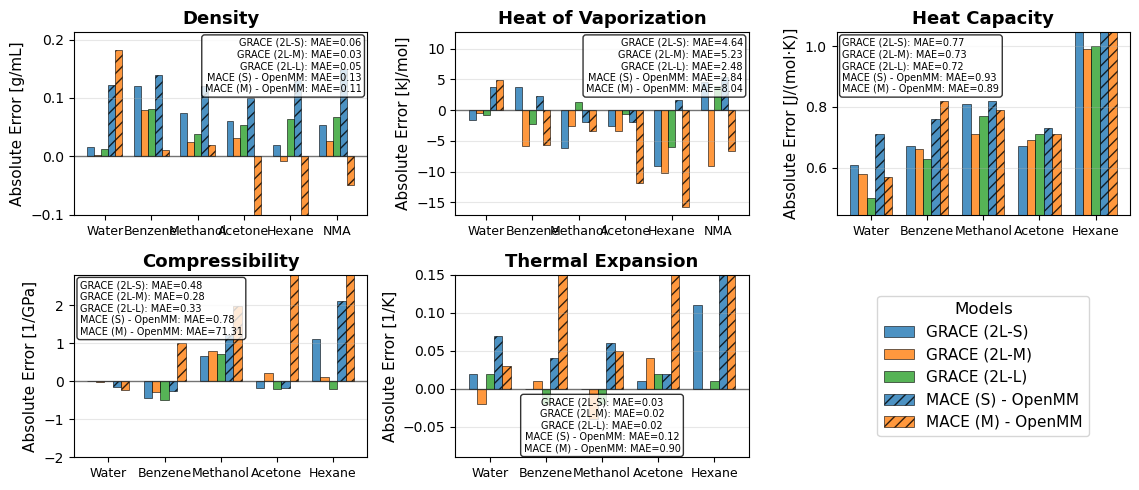

In [9]:
# Create comprehensive plot with all properties
fig, axes = plt.subplots(2, 3, figsize=(11.5, 5))
axes = axes.flatten()

# Get experimental data
exp_data = df_clean[df_clean["model"] == "experiment"]
# Include all models except experiment
model_data = df_clean[df_clean["model"] != "experiment"]

# Define colors for model sizes (S, M, L)
size_colors = {
    "S": "#1f77b4",  # blue
    "M": "#ff7f0e",  # orange
    "L": "#2ca02c",  # green
}

# Get unique solutes and models
solutes = exp_data["solute"].unique()
models = model_data["model"].unique()

# Define properties to plot with solutes to exclude
properties = [
    ('density', 'Density', '[g/mL]', []),
    ('heat_of_vaporization', 'Heat of Vaporization', '[kJ/mol]', []),
    ('heat_capacity', 'Heat Capacity', '[J/(mol·K)]', ['NMA']),
    ('compressibility', 'Compressibility', '[1/GPa]', ['NMA']),
    ('thermal_expansion', 'Thermal Expansion', '[1/K]', ['NMA'])
]

# Store handles and labels for the legend
legend_handles = []
legend_labels = []

# Plot each property
for idx, (prop_name, prop_title, prop_unit, exclude_solutes) in enumerate(properties):
    ax = axes[idx]
    
    # Filter solutes for this property
    property_solutes = [s for s in solutes if s not in exclude_solutes]
    
    # Calculate differences for each model and solute
    differences_data = []
    
    for model in models:
        model_subset = model_data[model_data["model"] == model]
        
        # Determine model size for color
        model_size = None
        if "(2L-S)" in model or "(S)" in model:
            model_size = "S"
        elif "(2L-M)" in model or "(M)" in model:
            model_size = "M"
        elif "(2L-L)" in model or "(L)" in model:
            model_size = "L"
        
        color = size_colors.get(model_size, "gray")
        
        for solute in property_solutes:
            exp_val = exp_data[exp_data["solute"] == solute][prop_name].values
            mod_val = model_subset[model_subset["solute"] == solute][prop_name].values
            
            if len(exp_val) > 0 and len(mod_val) > 0:
                exp_v = exp_val[0]
                mod_v = mod_val[0]
                
                # Check if values are numeric (not strings)
                if pd.notna(exp_v) and pd.notna(mod_v):
                    try:
                        # Try to convert to float to ensure they're numeric
                        exp_v = float(exp_v)
                        mod_v = float(mod_v)
                        diff = mod_v - exp_v
                        differences_data.append({
                            'model': model,
                            'solute': solute,
                            'difference': diff,
                            'color': color
                        })
                    except (ValueError, TypeError):
                        # Skip if conversion fails (e.g., string values)
                        continue
    
    # Create DataFrame for plotting
    df_diff = pd.DataFrame(differences_data)
    
    # Create grouped bar plot
    x = np.arange(len(property_solutes))
    width = 0.15
    offsets = np.linspace(-width * (len(models)-1)/2, width * (len(models)-1)/2, len(models))
    
    # Store MAE and RMSE for text box
    metrics_text = []
    
    for i, model in enumerate(models):
        model_data_subset = df_diff[df_diff['model'] == model]
        values = []
        colors_list = []
        
        for solute in property_solutes:
            solute_data = model_data_subset[model_data_subset['solute'] == solute]
            if len(solute_data) > 0:
                values.append(solute_data['difference'].values[0])
                colors_list.append(solute_data['color'].values[0])
            else:
                values.append(0)
                colors_list.append('gray')
        
        # Calculate MAE for this model
        mae = np.mean(np.abs(values))
        metrics_text.append(f"{model}: MAE={mae:.2f}")
        
        # Add hatch pattern for MACE models
        hatch = '///' if 'MACE' in model else None
        
        bars = ax.bar(x + offsets[i], values, width, label=f"{model}", 
               color=colors_list[0], alpha=0.8, hatch=hatch, edgecolor='black', linewidth=0.5)
        
        # Store handles and labels for legend (only from first subplot)
        if idx == 0:
            legend_handles.append(bars)
            legend_labels.append(model)
    
    # Add zero line
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    
    ax.set_xlabel('', fontsize=11)
    ax.set_ylabel(f'Absolute Error {prop_unit}', fontsize=11)
    ax.set_title(f'{prop_title}', fontweight='bold', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(property_solutes, rotation=0, fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    
    # Apply outlier detection and rescale y-axis
    all_values = df_diff['difference'].values
    if len(all_values) > 0:
        q1 = np.percentile(all_values, 25)
        q3 = np.percentile(all_values, 75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        ax.set_ylim(lower_bound, upper_bound)
    
    # Add text box with MAE
    textstr = '\n'.join(metrics_text)
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    
    # Adjust text box position based on subplot
    if idx in [2, 3]:  # Heat capacity and compressibility
        ax.text(0.02, 0.97, textstr, transform=ax.transAxes, fontsize=7,
                verticalalignment='top', horizontalalignment='left', bbox=props)
    elif idx == 4:  # Thermal expansion
        ax.text(0.5, 0.02, textstr, transform=ax.transAxes, fontsize=7,
                verticalalignment='bottom', horizontalalignment='center', bbox=props)
    else:
        ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=7,
                verticalalignment='top', horizontalalignment='right', bbox=props)

# Use the 6th subplot for the legend
axes[5].axis('off')
axes[5].legend(legend_handles, legend_labels, loc='center', fontsize=11, 
               title='Models', title_fontsize=12, frameon=True)

plt.tight_layout()
plt.show()

In [13]:
# Create dataframes to store MAE and RMSE values for each model and property
mae_data = []
rmse_data = []

# Get experimental data
exp_data = df_clean[df_clean["model"] == "experiment"]
# Include all models except experiment
model_data = df_clean[df_clean["model"] != "experiment"]

# Get unique solutes and models
solutes = exp_data["solute"].unique()
models = model_data["model"].unique()

# Define properties to plot with solutes to exclude
properties = [
    ('density', 'Density', '[g/mL]', []),
    ('heat_of_vaporization', 'Heat of Vaporization', '[kJ/mol]', []),
    ('heat_capacity', 'Heat Capacity', '[J/(mol·K)]', ['NMA']),
    ('compressibility', 'Compressibility', '[1/GPa]', ['NMA']),
    ('thermal_expansion', 'Thermal Expansion', '[1/K]', ['NMA'])
]

# Calculate MAE and RMSE for each property and model
for prop_name, prop_title, prop_unit, exclude_solutes in properties:
    # Filter solutes for this property
    property_solutes = [s for s in solutes if s not in exclude_solutes]
    
    # Calculate differences for each model and solute
    differences_data = []
    
    for model in models:
        model_subset = model_data[model_data["model"] == model]
        
        for solute in property_solutes:
            exp_val = exp_data[exp_data["solute"] == solute][prop_name].values
            mod_val = model_subset[model_subset["solute"] == solute][prop_name].values
            
            if len(exp_val) > 0 and len(mod_val) > 0:
                exp_v = exp_val[0]
                mod_v = mod_val[0]
                
                if pd.notna(exp_v) and pd.notna(mod_v):
                    try:
                        exp_v = float(exp_v)
                        mod_v = float(mod_v)
                        diff = mod_v - exp_v
                        differences_data.append({
                            'model': model,
                            'solute': solute,
                            'difference': diff
                        })
                    except (ValueError, TypeError):
                        continue
    
    # Create DataFrame for this property
    df_diff = pd.DataFrame(differences_data)
    
    # Calculate MAE and RMSE for each model
    for model in models:
        model_data_subset = df_diff[df_diff['model'] == model]
        values = []
        
        for solute in property_solutes:
            solute_data = model_data_subset[model_data_subset['solute'] == solute]
            if len(solute_data) > 0:
                values.append(solute_data['difference'].values[0])
        
        if len(values) > 0:
            mae = np.mean(np.abs(values))
            rmse = np.sqrt(np.mean(np.array(values)**2))
            
            mae_data.append({
                'Model': model,
                'Property': prop_title,
                'MAE': round(mae, 2)
            })
            
            rmse_data.append({
                'Model': model,
                'Property': prop_title,
                'RMSE': round(rmse, 2)
            })

# Create MAE dataframe
mae_df = pd.DataFrame(mae_data)
mae_pivot = mae_df.pivot(index='Model', columns='Property', values='MAE')

print("MAE values for each property and model:")
print(mae_pivot)
print()

# Create RMSE dataframe
rmse_df = pd.DataFrame(rmse_data)
rmse_pivot = rmse_df.pivot(index='Model', columns='Property', values='RMSE')

print("RMSE values for each property and model:")
print(rmse_pivot)

# Save to CSV files
mae_pivot.to_csv('model_mae_by_property.csv')
rmse_pivot.to_csv('model_rmse_by_property.csv')

print("\nMAE values saved to 'model_mae_by_property.csv'")
print("RMSE values saved to 'model_rmse_by_property.csv'")

MAE values for each property and model:
Property           Compressibility  Density  Heat Capacity  \
Model                                                        
GRACE (2L-L)                  0.33     0.05           0.72   
GRACE (2L-M)                  0.28     0.03           0.73   
GRACE (2L-S)                  0.48     0.06           0.77   
MACE (M) - OpenMM            71.31     0.11           0.89   
MACE (S) - OpenMM             0.78     0.13           0.93   

Property           Heat of Vaporization  Thermal Expansion  
Model                                                       
GRACE (2L-L)                       2.48               0.02  
GRACE (2L-M)                       5.23               0.02  
GRACE (2L-S)                       4.64               0.03  
MACE (M) - OpenMM                  8.04               0.90  
MACE (S) - OpenMM                  2.84               0.12  

RMSE values for each property and model:
Property           Compressibility  Density  Heat Capaci

TypeError: unsupported operand type(s) for -: 'str' and 'str'

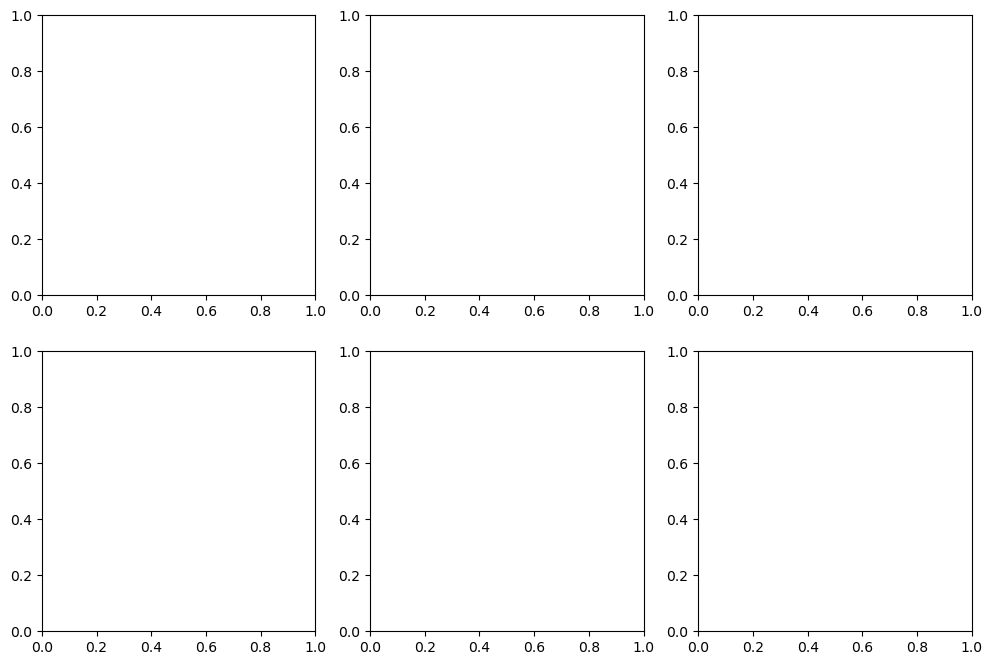

In [ ]:
# Create comprehensive plot organized by solute (properties on x-axis)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

# Get experimental data
exp_data = df_clean[df_clean["model"] == "experiment"]
# Include all models except experiment
model_data = df_clean[df_clean["model"] != "experiment"]

# Define colors for model sizes (S, M, L)
size_colors = {
    "S": "#1f77b4",  # blue
    "M": "#ff7f0e",  # orange
    "L": "#2ca02c",  # green
}

# Get unique solutes and models
solutes = exp_data["solute"].unique()
models = model_data["model"].unique()

# Define properties to plot - only density and HoV for NMA
properties_full = [
    ('density', 'Density', '[g/mL]'),
    ('heat_of_vaporization', 'HoV', '[kJ/mol]'),
    ('heat_capacity', 'Heat Cap.', '[J/(mol·K)]'),
    ('compressibility', 'Compress.', '[1/GPa]'),
    ('thermal_expansion', 'Therm. Exp.', '[1/K]')
]

properties_nma = [
    ('density', 'Density', '[g/mL]'),
    ('heat_of_vaporization', 'HoV', '[kJ/mol]')
]

# Store handles and labels for the legend
legend_handles = []
legend_labels = []

# Plot each solute
for idx, solute in enumerate(solutes):
    ax = axes[idx]
    
    # Select appropriate properties for this solute
    properties = properties_nma if solute == 'NMA' else properties_full
    
    # Calculate differences for each model and property
    differences_data = []
    
    for model in models:
        model_subset = model_data[model_data["model"] == model]
        
        # Determine model size for color
        model_size = None
        if "(2L-S)" in model or "(S)" in model:
            model_size = "S"
        elif "(2L-M)" in model or "(M)" in model:
            model_size = "M"
        elif "(2L-L)" in model or "(L)" in model:
            model_size = "L"
        
        color = size_colors.get(model_size, "gray")
        
        for prop_name, prop_short, prop_unit in properties:
            exp_val = exp_data[exp_data["solute"] == solute][prop_name].values
            mod_val = model_subset[model_subset["solute"] == solute][prop_name].values
            
            if len(exp_val) > 0 and len(mod_val) > 0:
                exp_v = exp_val[0]
                mod_v = mod_val[0]
                
                if pd.notna(exp_v) and pd.notna(mod_v):
                    try:
                        # Try to convert to float to ensure they're numeric
                        exp_v = float(exp_v)
                        mod_v = float(mod_v)
                        diff = mod_v - exp_v
                        differences_data.append({
                            'model': model,
                            'property': prop_short,
                            'difference': diff,
                            'color': color
                        })
                    except (ValueError, TypeError):
                        # Skip if conversion fails (e.g., string values)
                        continue
    
    # Create DataFrame for plotting
    df_diff = pd.DataFrame(differences_data)
    
    # Create grouped bar plot
    prop_labels = [prop[1] for prop in properties]
    x = np.arange(len(prop_labels))
    width = 0.15
    offsets = np.linspace(-width * (len(models)-1)/2, width * (len(models)-1)/2, len(models))
    
    # Store MAE and RMSE for text box
    metrics_text = []
    
    for i, model in enumerate(models):
        model_data_subset = df_diff[df_diff['model'] == model]
        values = []
        colors_list = []
        
        for prop_short in prop_labels:
            prop_data = model_data_subset[model_data_subset['property'] == prop_short]
            if len(prop_data) > 0:
                values.append(prop_data['difference'].values[0])
                colors_list.append(prop_data['color'].values[0])
            else:
                values.append(0)
                colors_list.append('gray')
        
        # Calculate MAE and RMSE for this model across all properties
        mae = np.mean(np.abs(values))
        rmse = np.sqrt(np.mean(np.array(values)**2))
        metrics_text.append(f"{model}: MAE={mae:.2f}, RMSE={rmse:.2f}")
        
        # Add hatch pattern for MACE models
        hatch = '///' if 'MACE' in model else None
        
        bars = ax.bar(x + offsets[i], values, width, label=f"{model}", 
               color=colors_list[0], alpha=0.8, hatch=hatch, edgecolor='black', linewidth=0.5)
        
        # Store handles and labels for legend (only from first subplot)
        if idx == 0:
            legend_handles.append(bars)
            legend_labels.append(model)
    
    # Add zero line
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    
    ax.set_ylabel('Absolute Error', fontsize=11)
    ax.set_title(f'{solute.capitalize()}', fontweight='bold', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(prop_labels, rotation=45, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    
    # Apply outlier detection and rescale y-axis
    all_values = df_diff['difference'].values
    if len(all_values) > 0:
        q1 = np.percentile(all_values, 25)
        q3 = np.percentile(all_values, 75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        ax.set_ylim(lower_bound, upper_bound)
    
    # Add text box with MAE and RMSE
    textstr = '\n'.join(metrics_text)
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    
    # Adjust text box position based on subplot
    if idx in [2, 3]:  # Acetone and benzene
        ax.text(0.02, 0.97, textstr, transform=ax.transAxes, fontsize=7,
                verticalalignment='top', horizontalalignment='left', bbox=props)
    elif idx == 4:  # N-hexane
        ax.text(0.5, 0.02, textstr, transform=ax.transAxes, fontsize=7,
                verticalalignment='bottom', horizontalalignment='center', bbox=props)
    else:
        ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=7,
                verticalalignment='top', horizontalalignment='right', bbox=props)

# Use the 6th subplot for the legend
axes[5].axis('off')
axes[5].legend(legend_handles, legend_labels, loc='center', fontsize=11, 
               title='Models', title_fontsize=12, frameon=True)

plt.tight_layout()
plt.show()

TypeError: unsupported operand type(s) for -: 'str' and 'str'

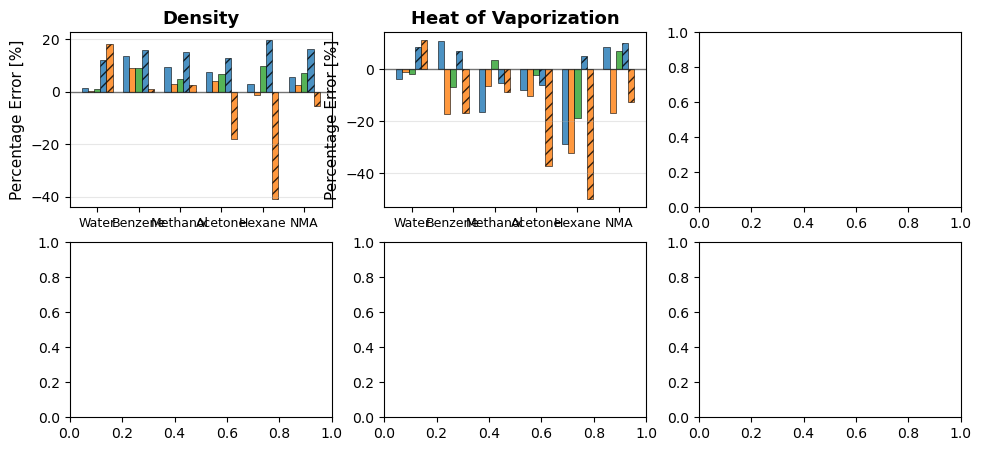

In [ ]:
# Create comprehensive plot with all properties using percentage error
fig, axes = plt.subplots(2, 3, figsize=(11.5, 5))
axes = axes.flatten()

# Get experimental data
exp_data = df_clean[df_clean["model"] == "experiment"]
# Include all models except experiment
model_data = df_clean[df_clean["model"] != "experiment"]

# Define colors for model sizes (S, M, L)
size_colors = {
    "S": "#1f77b4",  # blue
    "M": "#ff7f0e",  # orange
    "L": "#2ca02c",  # green
}

# Get unique solutes and models
solutes = exp_data["solute"].unique()
models = model_data["model"].unique()

# Define properties to plot with solutes to exclude
properties = [
    ('density', 'Density', '[%]', []),
    ('heat_of_vaporization', 'Heat of Vaporization', '[%]', []),
    ('heat_capacity', 'Heat Capacity', '[%]', ['NMA']),
    ('compressibility', 'Compressibility', '[%]', ['NMA']),
    ('thermal_expansion', 'Thermal Expansion', '[%]', ['NMA'])
]

# Store handles and labels for the legend
legend_handles = []
legend_labels = []

# Plot each property
for idx, (prop_name, prop_title, prop_unit, exclude_solutes) in enumerate(properties):
    ax = axes[idx]
    
    # Filter solutes for this property
    property_solutes = [s for s in solutes if s not in exclude_solutes]
    
    # Calculate percentage errors for each model and solute
    differences_data = []
    
    for model in models:
        model_subset = model_data[model_data["model"] == model]
        
        # Determine model size for color
        model_size = None
        if "(2L-S)" in model or "(S)" in model:
            model_size = "S"
        elif "(2L-M)" in model or "(M)" in model:
            model_size = "M"
        elif "(2L-L)" in model or "(L)" in model:
            model_size = "L"
        
        color = size_colors.get(model_size, "gray")
        
        for solute in property_solutes:
            exp_val = exp_data[exp_data["solute"] == solute][prop_name].values
            mod_val = model_subset[model_subset["solute"] == solute][prop_name].values
            
            if len(exp_val) > 0 and len(mod_val) > 0:
                exp_v = exp_val[0]
                mod_v = mod_val[0]
                
                if pd.notna(exp_v) and pd.notna(mod_v):
                    try:
                        # Try to convert to float to ensure they're numeric
                        exp_v = float(exp_v)
                        mod_v = float(mod_v)
                        if exp_v != 0:
                            # Calculate percentage error: (model - exp) / exp * 100
                            pct_error = ((mod_v - exp_v) / exp_v) * 100
                            differences_data.append({
                                'model': model,
                                'solute': solute,
                                'difference': pct_error,
                                'color': color
                            })
                    except (ValueError, TypeError):
                        # Skip if conversion fails (e.g., string values)
                        continue
    
    # Create DataFrame for plotting
    df_diff = pd.DataFrame(differences_data)
    
    # Create grouped bar plot
    x = np.arange(len(property_solutes))
    width = 0.15
    offsets = np.linspace(-width * (len(models)-1)/2, width * (len(models)-1)/2, len(models))
    
    # Store MAPE (Mean Absolute Percentage Error) for text box
    metrics_text = []
    
    for i, model in enumerate(models):
        model_data_subset = df_diff[df_diff['model'] == model]
        values = []
        colors_list = []
        
        for solute in property_solutes:
            solute_data = model_data_subset[model_data_subset['solute'] == solute]
            if len(solute_data) > 0:
                values.append(solute_data['difference'].values[0])
                colors_list.append(solute_data['color'].values[0])
            else:
                values.append(0)
                colors_list.append('gray')
        
        # Calculate MAPE for this model
        mape = np.mean(np.abs(values))
        metrics_text.append(f"{model}: MAPE={mape:.2f}%")
        
        # Add hatch pattern for MACE models
        hatch = '///' if 'MACE' in model else None
        
        bars = ax.bar(x + offsets[i], values, width, label=f"{model}", 
               color=colors_list[0], alpha=0.8, hatch=hatch, edgecolor='black', linewidth=0.5)
        
        # Store handles and labels for legend (only from first subplot)
        if idx == 0:
            legend_handles.append(bars)
            legend_labels.append(model)
    
    # Add zero line
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    
    ax.set_xlabel('', fontsize=11)
    ax.set_ylabel(f'Percentage Error {prop_unit}', fontsize=11)
    ax.set_title(f'{prop_title}', fontweight='bold', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(property_solutes, rotation=0, fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    


# Use the 6th subplot for the legend
axes[5].axis('off')
axes[5].legend(legend_handles, legend_labels, loc='center', fontsize=11, 
               title='Models', title_fontsize=12, frameon=True)

plt.tight_layout()
plt.show()